In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
try:
    import marimo as mo
except ModuleNotFoundError:
    mo = None


# Reading the data

In [2]:
file = scipy.io.loadmat(
    "Data/Data/Gap/gap_data_raw_dorsal_wt_time_series.mat", simplify_cells=True
)
data = file["data"]

In [3]:
len(file["data"])

292

In [4]:
file["data"][0]

{'index': 1,
 'orient': 1,
 'dist': 32.573461226127016,
 'age': 56.97888721130548,
 'genotype': 1,
 'Kni': array([         nan,          nan,          nan,          nan,
                 nan,          nan,          nan,          nan,
                 nan,          nan,          nan,          nan,
                 nan,          nan,          nan,          nan,
                 nan, 527.33333333, 536.33333333, 516.33333333,
        508.53333333, 498.77272727, 501.525     , 504.43137255,
        506.48412698, 507.80921053, 506.26111111, 503.47826087,
        497.98283262, 496.29844961, 492.80851064, 493.47297297,
        492.6097561 , 490.73287671, 488.62116041, 485.95890411,
        485.62939297, 486.15635179, 490.27516779, 491.81118881,
        498.01102941, 500.72932331, 503.89230769, 510.5984252 ,
        517.324     , 529.89545455, 536.58604651, 542.90952381,
        545.6097561 , 542.83870968, 539.12264151, 535.42512077,
        531.591133  , 526.45454545, 521.1761658 , 515.28042328

In [5]:
columns = file["data"][0].keys()
lencount = np.zeros(292)

df = pd.DataFrame(columns=columns, data=file["data"])
ts_l = ["Kni", "Kr", "Gt", "Hb"]
for i, row in df.iterrows():
    mask = np.isnan(row["Kni"])
    lencount[i] = sum(mask)

row_length = len(df)
cleaned_lengths = []
for _, _row in df.iterrows():
    for _key in ts_l:
        series = np.asarray(_row[_key])
        cleaned_lengths.append(np.sum(~np.isnan(series)))

best_len = int(np.min(cleaned_lengths))
matrix = np.empty((row_length, len(ts_l), best_len), dtype=float)

for _i, _row in df.iterrows():
    for _j, _key in enumerate(ts_l):
        series = np.asarray(_row[_key])
        cleaned = series[~np.isnan(series)]
        matrix[_i, _j, :] = cleaned[:best_len]

matrix = np.transpose(matrix, (0, 2, 1))

In [6]:
# 4 columns, w/ variables, consistent within a single cell.
# Transform into matrix form?

In [7]:
import torch
import torch.nn as nn
import torch.functional as F


In [8]:
class Autoencoder(torch.nn.Module):
    def __init__(self, input_dim=4, latent_dim=2):
        super().__init__()
        self.encoder = torch.nn.Sequential(
            torch.nn.Linear(input_dim, latent_dim),
            torch.nn.ReLU(),
        )
        self.decoder = torch.nn.Sequential(
            torch.nn.Linear(latent_dim, input_dim),
        )

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)


In [9]:
matrix.shape

(292, 958, 4)

# Reproducing figure
Fig.1C - making sure I'm correctly reading the dataset; The figure below looks very similar.

In [10]:
sample_index = 3

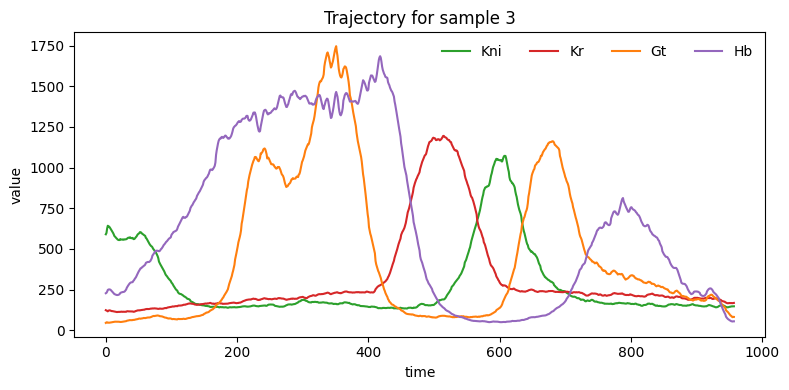

In [11]:
trajectory = matrix[sample_index]
time = np.arange(trajectory.shape[0])
fig, ax = plt.subplots(figsize=(8, 4))
colors = ["tab:green", "tab:red","tab:orange",  "tab:purple" ]

for idx, color in enumerate(colors):
    ax.plot(time, trajectory[:, idx], lw=1.5, color=color, label=ts_l[idx])
ax.set_xlabel("time")
ax.set_ylabel("value")
ax.set_title(f"Trajectory for sample {sample_index}")
ax.legend(ncol=4, frameon=False, loc="upper right")
plt.tight_layout()
plt.show()


In the paper it seems to be normalized. We can try it both ways during training to see if it makes a difference. 

### Normalization try #1 - scale by max of its own type

In [12]:
t = torch.tensor(matrix)
t.shape

torch.Size([292, 958, 4])

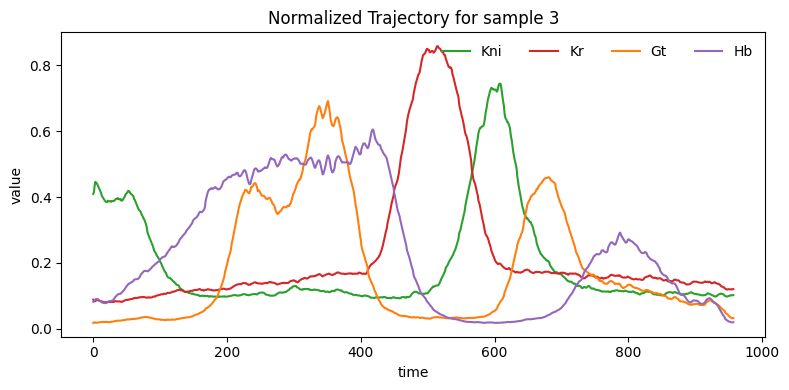

In [13]:

t_norm1 = t / t.amax((0,1))
trajectory = t_norm1[sample_index]

time = np.arange(trajectory.shape[0])
fig, ax = plt.subplots(figsize=(8, 4))
colors = ["tab:green", "tab:red","tab:orange",  "tab:purple" ]

for idx, color in enumerate(colors):
    ax.plot(time, trajectory[:, idx], lw=1.5, color=color, label=ts_l[idx])
ax.set_xlabel("time")
ax.set_ylabel("value")
ax.set_title(f"Normalized Trajectory for sample {sample_index}")
ax.legend(ncol=4, frameon=False, loc="upper right")
plt.tight_layout()
plt.show()


The y_max is now the same as in the paper, but the plot itself is not quite identical. Maybe it is not actually the same datapoint that I'm looking at?
Actually, it strikes me that the paper's figure seems to be also normalized by min. Let's try that as well in addition to max.
### Min-Max norml

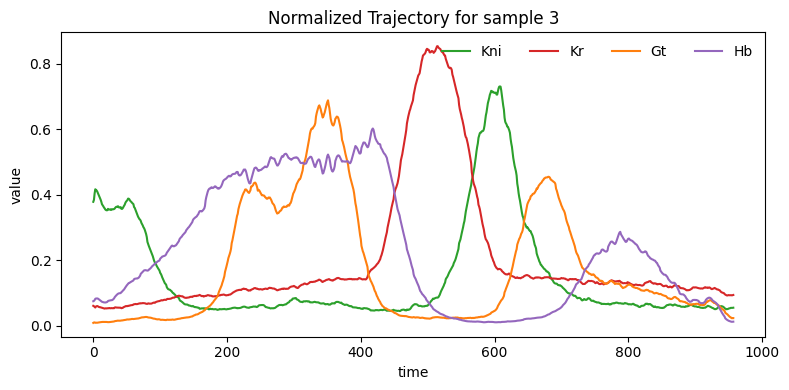

In [14]:

t_min = t.amin((0,1))
t_max = t.amax((0,1))

t_norm2 = ( t - t_min ) / ( t_max - t_min )
trajectory = t_norm2[sample_index]

time = np.arange(trajectory.shape[0])
fig, ax = plt.subplots(figsize=(8, 4))
colors = ["tab:green", "tab:red","tab:orange",  "tab:purple" ]

for idx, color in enumerate(colors):
    ax.plot(time, trajectory[:, idx], lw=1.5, color=color, label=ts_l[idx])
ax.set_xlabel("time")
ax.set_ylabel("value")
ax.set_title(f"Normalized Trajectory for sample {sample_index}")
ax.legend(ncol=4, frameon=False, loc="upper right")
plt.tight_layout()
plt.show()


In [ ]:
device = torch.device("cpu")
model = Autoencoder(input_dim=4, latent_dim=2).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = torch.nn.MSELoss()

data = torch.tensor(t_norm2, dtype=torch.float32).reshape(-1, t_norm2.shape[-1])
batch_size = 256
epochs = 20
loss_history = []

model.train()
for epoch in range(epochs):
    epoch_loss = 0.0
    for start in range(0, len(data), batch_size):
        batch = data[start : start + batch_size].to(device)
        optimizer.zero_grad()
        recon = model(batch)
        loss = criterion(recon, batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * batch.size(0)
    epoch_loss /= len(data)
    loss_history.append(epoch_loss)

plt.figure(figsize=(5, 3))
plt.plot(loss_history, marker="o", lw=1.2)
plt.xlabel("epoch")
plt.ylabel("mse loss")
plt.title("Autoencoder training loss")
plt.tight_layout()
plt.show()

model.eval()
with torch.no_grad():
    sample = torch.tensor(t_norm2[sample_index], dtype=torch.float32).to(device)
    recon_sample = model(sample).cpu().numpy()

time = np.arange(sample.shape[0])
fig, ax = plt.subplots(figsize=(8, 4))
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]
for idx, color in enumerate(colors):
    ax.plot(time, sample.cpu().numpy()[:, idx], color=color, lw=1.2, label=f"{ts_l[idx]} original")
    ax.plot(time, recon_sample[:, idx], color=color, lw=1.2, ls="--", label=f"{ts_l[idx]} recon")
ax.set_xlabel("time")
ax.set_ylabel("value")
ax.set_title(f"Reconstruction for sample {sample_index}")
ax.legend(ncol=2, frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

torch.save(model.state_dict(), "autoencoder.pt")
